# Community detection in complex networks

Basics:
* Communities are **locally dense connected subgraphs** in a network.
* Community detection aims to uncover the inherent community structure of a network.

Definitions:
* Clique - a fully connected subgraph within a larger graph.
* Strong community - each node has more edges connecting it to other nodes inside the group than to nodes outside the group.
* Weak community - the total internal degree of the group exceeds its total external degree.

Approaches and algorithms:
* Graph partitioning
* Hierarchical clustering (Girvan–Newman)
* Modularity optimization (Louvain)

## Introduction to community detection

Lets start with a simple example of a small graph.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

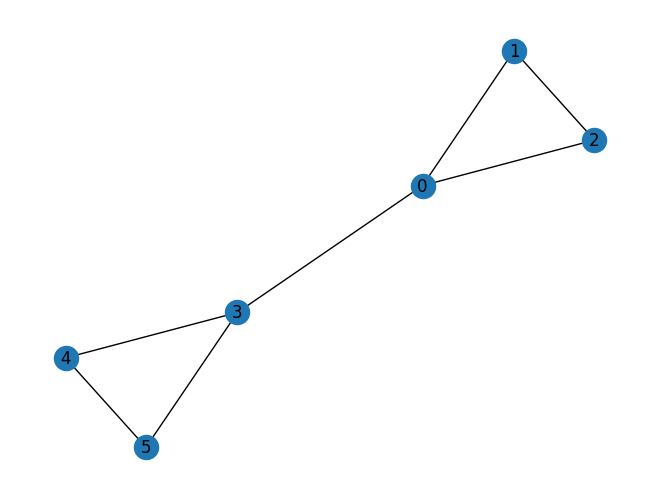

In [2]:
G = nx.Graph()
nx.add_cycle(G, [0, 1, 2])
nx.add_cycle(G, [3, 4, 5])
G.add_edge(0, 3)

nx.draw(G, with_labels=True)

How can we devide this graph into communities to get partitions of good quality? At first we'll do it by hand and validate if the partition is valid.

In [3]:
partition = [
    {0, 1, 2},
    {3, 4, 5},
]

nx.community.is_partition(G, partition)

True

Now, create a mapping between nodes and partitions, that will be of use for visualization and assesment of partition quality.

In [4]:
def create_node_to_partition_mapping(partition):
  node_to_partition = {}
  for idx, cluster_nodes in enumerate(partition):
      for node in cluster_nodes:
          node_to_partition[node] = idx
  return node_to_partition

node_to_partition = create_node_to_partition_mapping(partition)
node_to_partition

{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}

Then visualize this simple graph again with color of nodes corresponding to the partition they belong to.

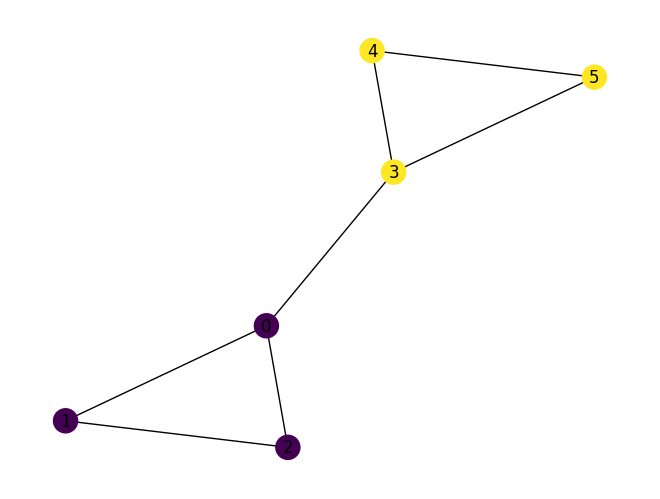

In [5]:
colors = [node_to_partition[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

## Modularity

Now with the defined partition, we need to look for an answer to the question of can we evaluate the goodness of this network partition, and in a broader context, any partition of any graph?

One possible answer is to compare the connection density of the groups to a random baseline, as random networks do not have groups.

The modularity measure is defined as the difference between the number of internal links in the clusters and the expected number of links in a random network.

$$Q = \frac{1}{L}\sum_C(L_C - \frac{k_C^2}{4L})$$

where:
- $L$ - total number of links
- $L_c$ - number of links inside cluster $C$
- $\frac{k_C^2}{4L}$ - number of links in a random network

NetworkX comes with an efficient implementation of modularity calculation ```nx.community.quality.modularity(G, partition)```, that we will use to measure partition quality.

In [6]:
nx.community.quality.modularity(G, partition)

0.35714285714285715

We can verify how the modularity value change if we decide to change the partition.

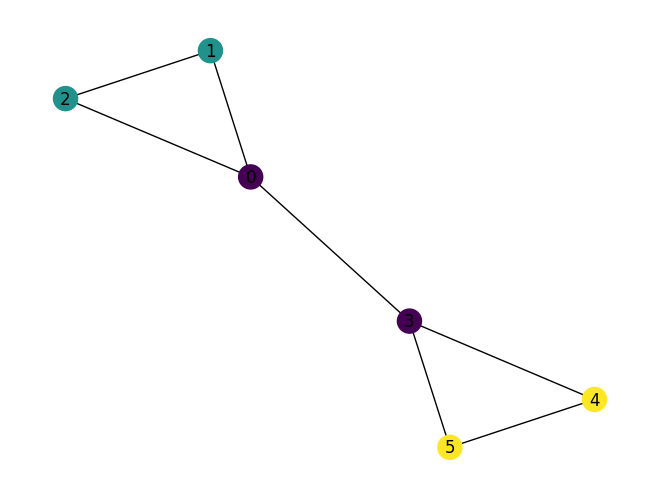

In [7]:
partition2 = [
    {0, 3},
    {1, 2},
    {4, 5},
]

colors = [create_node_to_partition_mapping(partition2)[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

In [8]:
nx.community.quality.modularity(G, partition2)

0.0816326530612245

## Setting up networks for study

In the next sections of this notebook, we will be working with different networks, both artificial and real-world and algorithms that will help us identify communities within those networks.

In [9]:
connected_caveman_graph = nx.connected_caveman_graph(4, 8)
small_world_network = nx.watts_strogatz_graph(34, 4, 0.15)
windmill_graph = nx.windmill_graph(5, 7)
gaussian_random_partition_graph = nx.gaussian_random_partition_graph(n=34, s=9, v=9, p_in=0.7, p_out=0.03, seed=42)
random_partition_graph = nx.random_partition_graph([10, 8, 5, 5, 3, 3], 0.8, 0.04, seed=42)
karate_club_network = nx.karate_club_graph()
graphs = {
    "Connected caveman graph": connected_caveman_graph, 
    "Small world network": small_world_network, 
    "Widmill graph": windmill_graph, 
    "Gaussian random partion graph": gaussian_random_partition_graph, 
    "Random partition": random_partition_graph, 
    "Karate club network": karate_club_network
}

### Task 1
The first task is to take a look at the networks that are going to be the subject of study. Prepare a visualization of the graphs defined in the previous cell. Place all of them on a single plot, remember to include subplot titles to be able to identify them and find the best positionig that helps to reveale the network structure.

#### Code

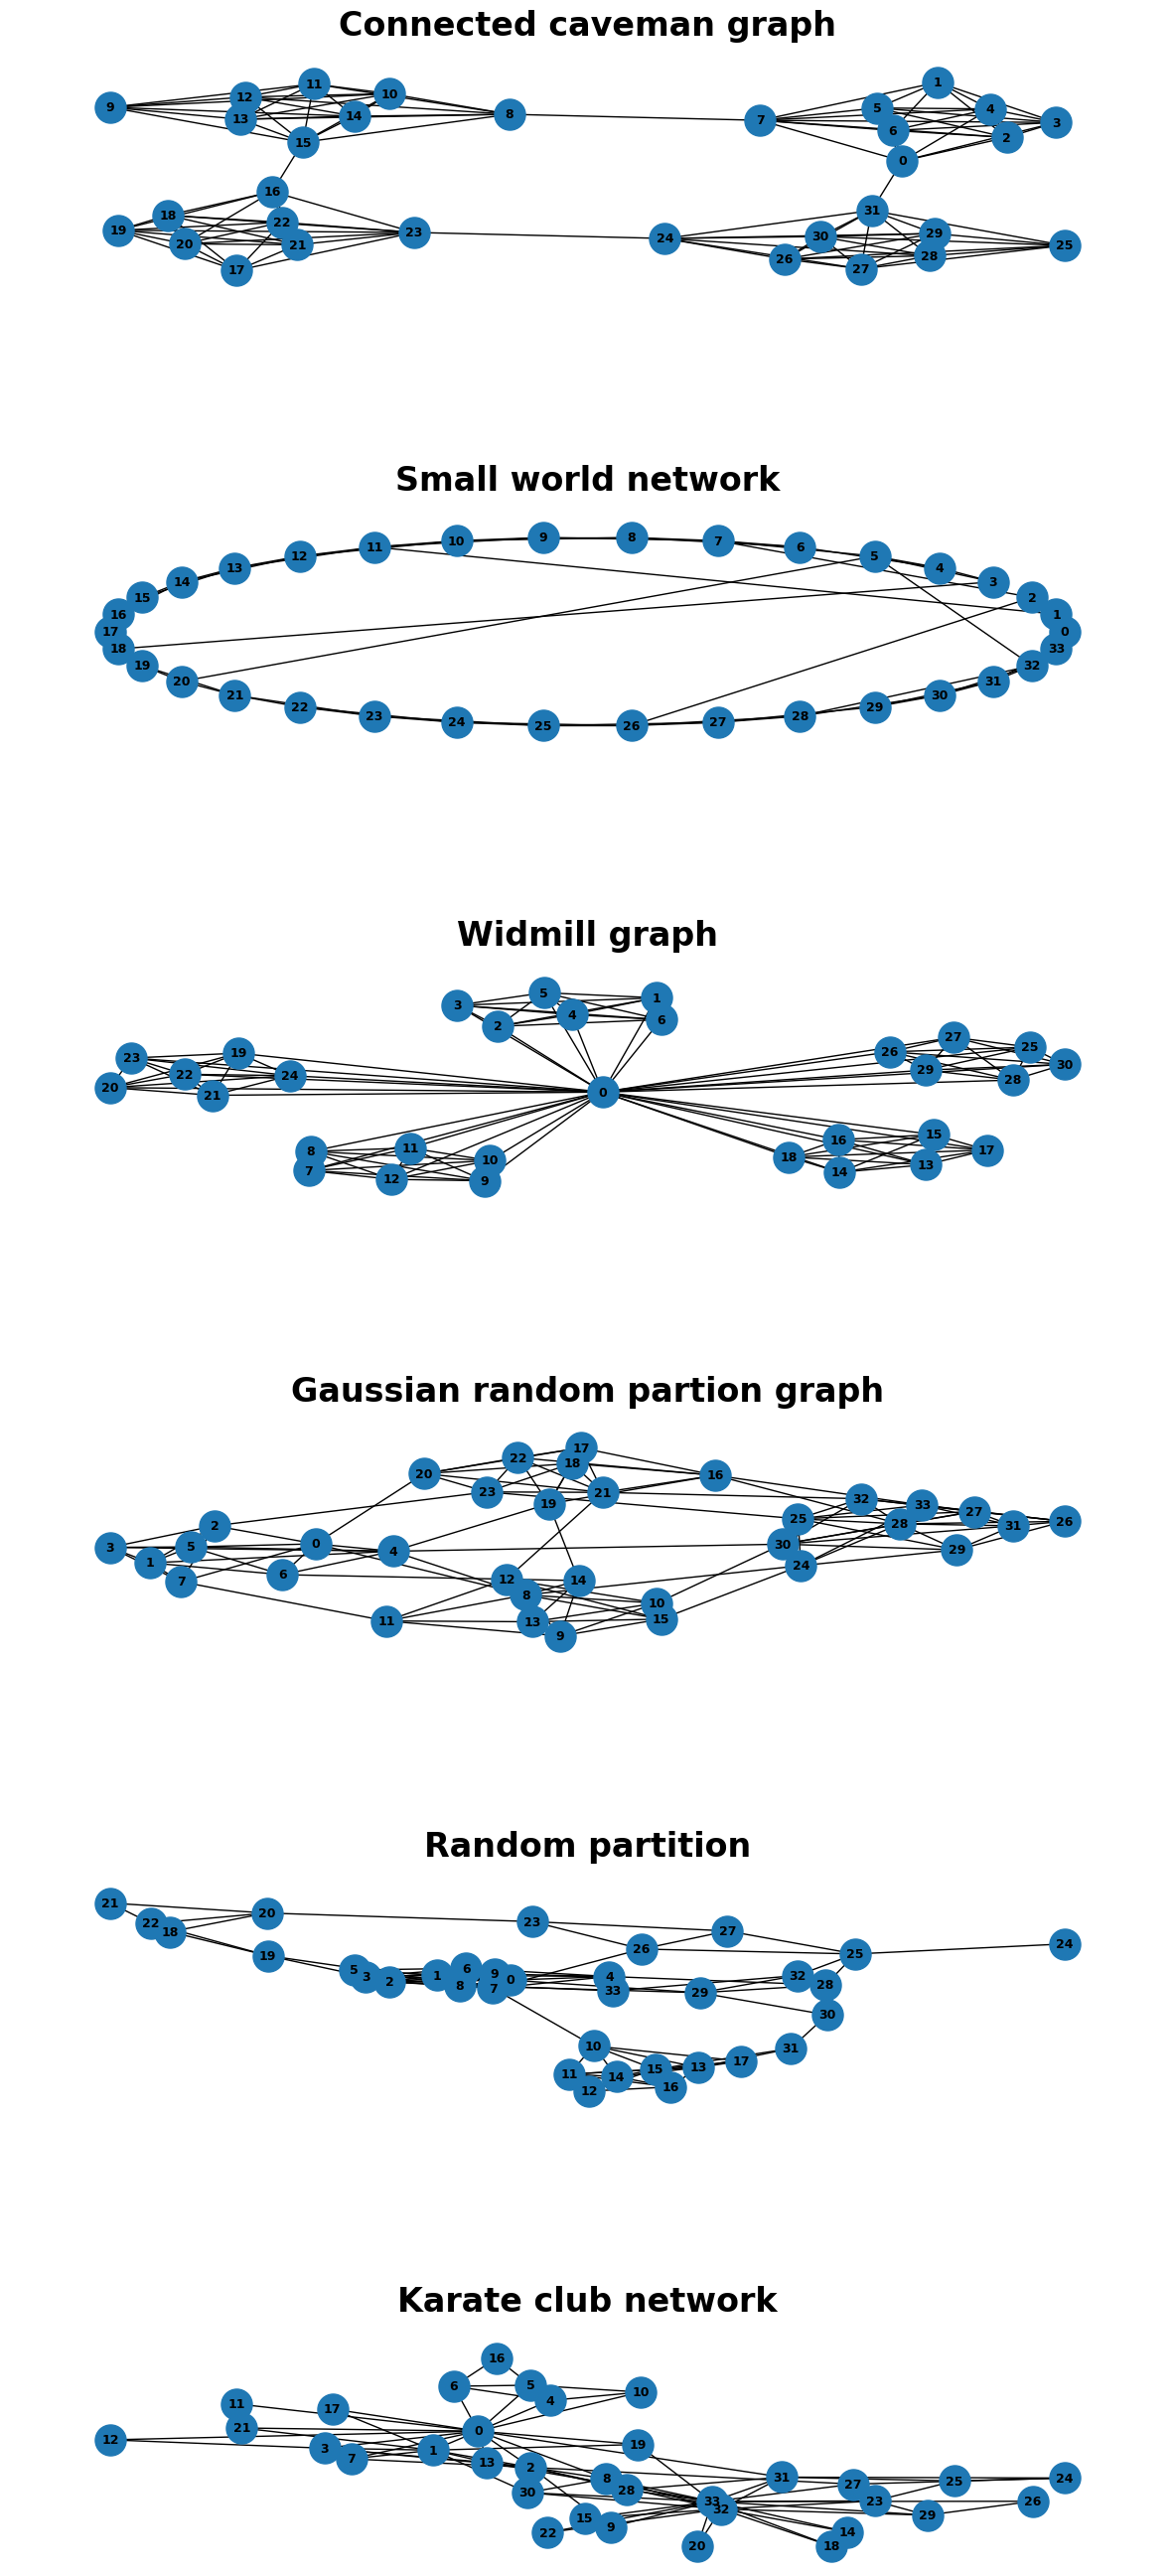

In [10]:
plt.style.use('default')
fig, axes = plt.subplots(6, 1, figsize=(15,30))
axes = axes.flatten()
for i, (name, graph) in enumerate(graphs.items()):
    if name == "Small world network":
        pos = nx.circular_layout(graph)
    elif name == "Connected caveman graph":
        pos = nx.kamada_kawai_layout(graph)
    else:
        pos = nx.spring_layout(graph, seed=42)

    axes[i].set_facecolor('white')
    nx.draw_networkx(
        graph,
        ax=axes[i],
        pos=pos,
        with_labels=True,
        node_size=500,
        font_size=9,
        font_weight='bold'
    )
    axes[i].axis('off')
    axes[i].set_title(name, fontsize=24, fontweight='bold', pad=20)

plt.subplots_adjust(hspace=1.0, top=0.95)
plt.show()

## Cliques identification

### Task 2
Calculate the number of different size cliques present in each network and visualize them on a barplot.

Analyse and interpret the obtained results, write your conclusions in the cell below. What does the number of cliques says about those networks? Are they differnt or quite similar?

#### Code

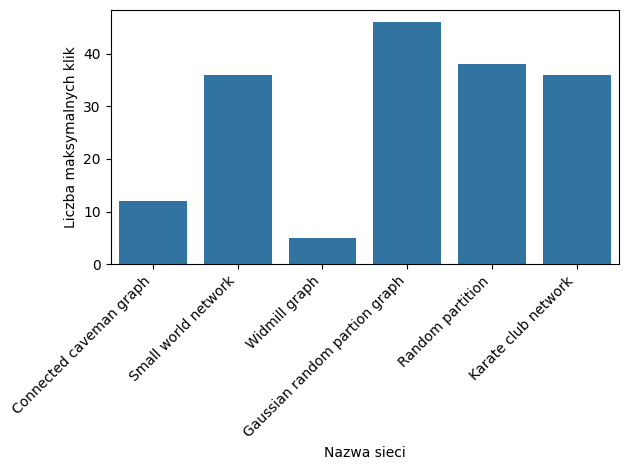

In [11]:
plt.style.use('default')

cliques = [len(list(nx.find_cliques(graph))) for _, graph in graphs.items()]
names = [name for name, _ in graphs.items()]

df_cliques = pd.DataFrame({
    'Nazwa sieci': names,
    'Liczba maksymalnych klik': cliques
})

sns.barplot(df_cliques, x="Nazwa sieci", y="Liczba maksymalnych klik", legend=False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Conclusions

* **Clear division** - the analyzed networks are quite different; they fall into two distinct groups—those with a very low (<15) and a very high (>35) number of cliques.
* **Low number of cliques (Windmill, Caveman)** - indicates highly structured, artificial networks consisting of a few strictly separated and isolated groups.
* **High number of cliques (Karate, Small world, random graphs)** - indicates a complex, more natural network structure where connections overlap, creating numerous small, interlocking subgroups.

## Hierarchical clustering using Girvan–Newman algorithm

The Girvan–Newman algorithm is a popular method for detecting communities in complex networks. It is based on the concept of edge betweenness centrality and operates by iteratively removing edges with the highest betweenness centrality. This process effectively breaks the network into smaller components, which can then be interpreted as communities.

The algorithm's steps
1. The betweenness of all existing edges in the network is calculated first.
2. The edge(s) with the highest betweenness are removed.
3. The betweenness of all edges affected by the removal is recalculated.
4. Steps 2 and 3 are repeated until no edges remain.

### Task 3
Use Girvan–Newman algorithm to detect communities among all studied networks. Use NetworkX function ```nx.algorithms.community.girvan_newman(G)```. Visualize and inspect obtained results for different numbers of communities. Find the best split for each network using modularity as a goodness measure and plot partitioned networks. Save the modularity results for each network for later comparison with other community detection method.

#### Code

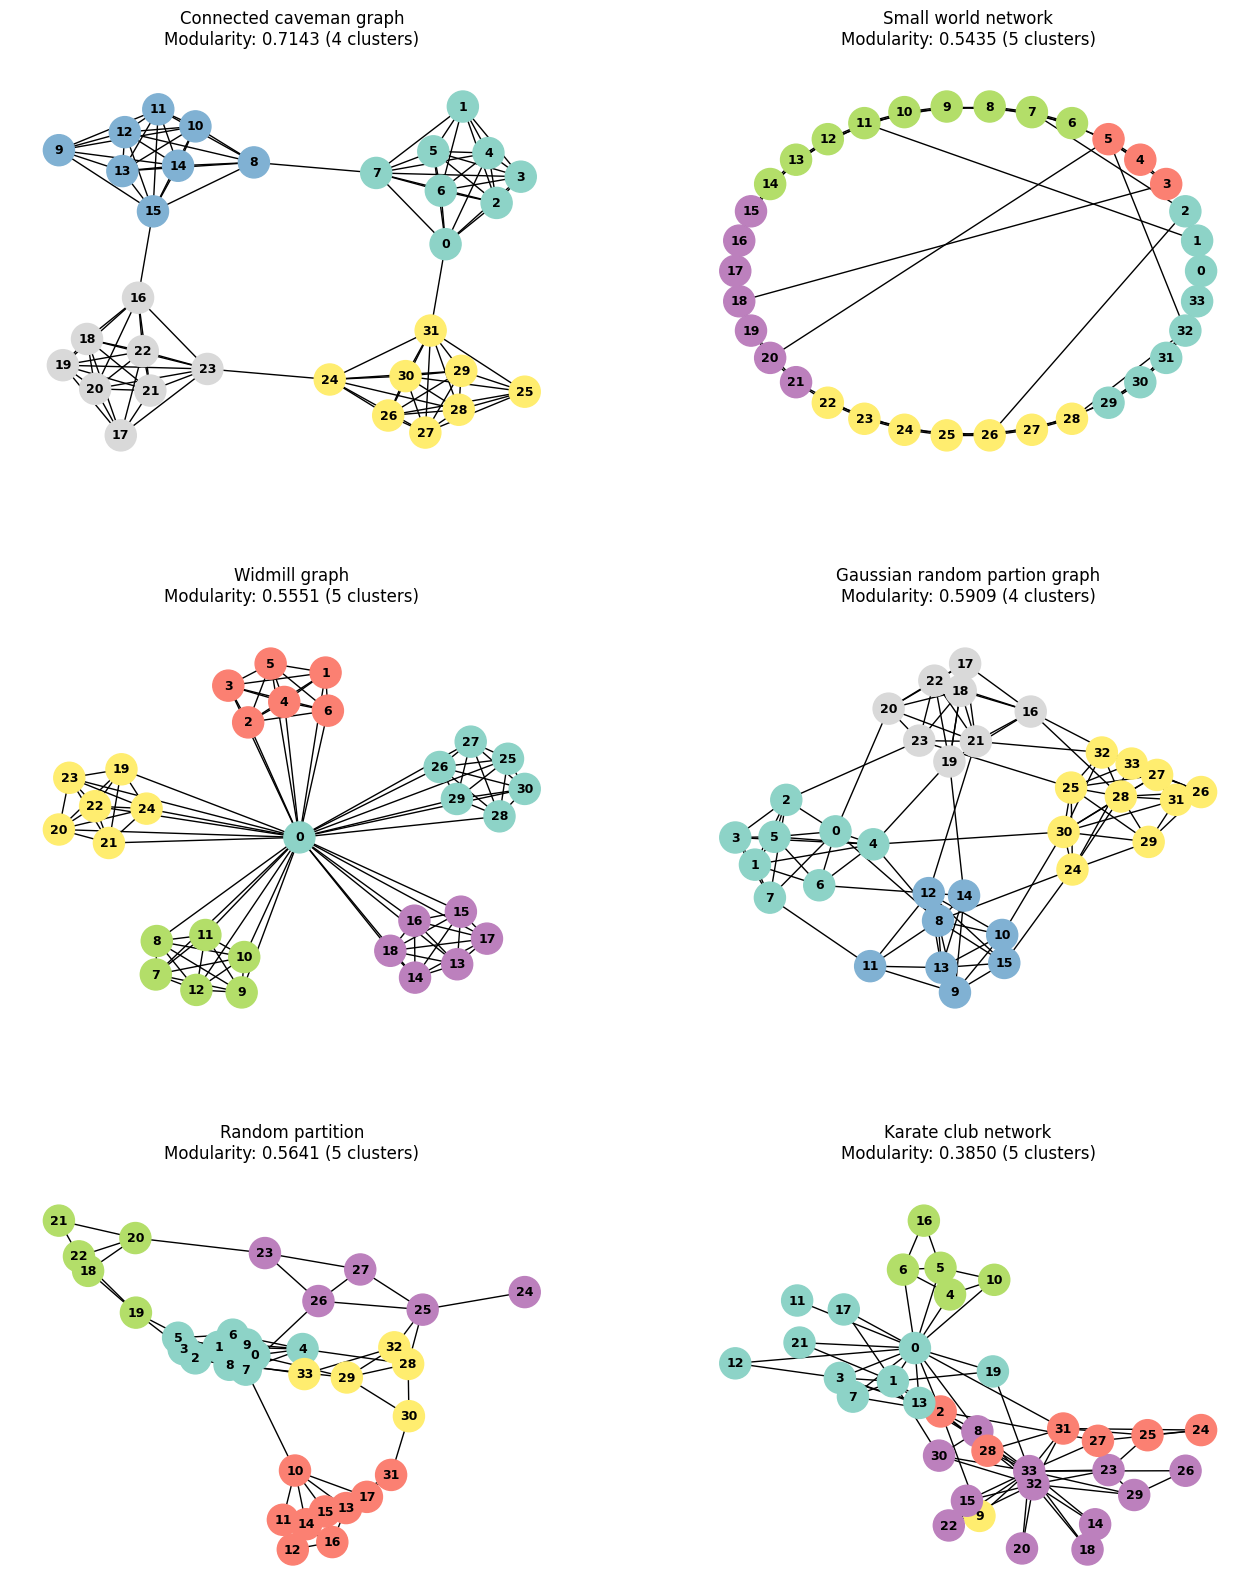

Best Modularity Scores (Girvan-Newman)
   Connected caveman graph: 0.7143
   Small world network: 0.5435
   Widmill graph: 0.5551
   Gaussian random partion graph: 0.5909
   Random partition: 0.5641
   Karate club network: 0.3850


In [12]:
from networkx.algorithms.community import girvan_newman, modularity

plt.style.use('default')

modularities_gn = {}
best_communities_gn = {}

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()
for i, (name, graph) in enumerate(graphs.items()):
    communities_generator = girvan_newman(graph)
    best_modularity = -1.0
    best_community = None

    for community in communities_generator:
        current_modularity = modularity(graph, community)

        if current_modularity > best_modularity:
            best_modularity = current_modularity
            best_community = community

    modularities_gn[name] = best_modularity
    best_communities_gn[name] = best_community

    node_to_community = {}
    for community_id, community in enumerate(best_community):
        for node in community:
            node_to_community[node] = community_id

    node_colors = [node_to_community[node] for node in graph.nodes()]

    if name == "Small world network":
        pos = nx.circular_layout(graph)
    elif name == "Connected caveman graph":
        pos = nx.kamada_kawai_layout(graph)
    else:
        pos = nx.spring_layout(graph, seed=42)

    axes[i].set_facecolor('white')
    nx.draw_networkx(
        graph,
        ax=axes[i],
        pos=pos,
        with_labels=True,
        node_color=node_colors,
        cmap=plt.cm.Set3,
        node_size=500,
        font_size=9,
        font_weight='bold'
    )
    axes[i].axis('off')
    axes[i].set_title(f"{name}\nModularity: {best_modularity:.4f} ({len(best_community)} clusters)", pad=20, fontsize=12)

plt.subplots_adjust(hspace=0.4, top=0.95)
plt.show()

print("Best Modularity Scores (Girvan-Newman)")
for name, score in modularities_gn.items():
    print(f"   {name}: {score:.4f}")

## Modularity based community detection using Louvain algorithm
The Louvain algorithm is the most popular community detection algorithm. Its operation is based on the optimization of modularity. Louvain can be used even with very large networks with millions of nodes and edges.

### Louvain algorithm
1. Start with each node assigned to its own group.
2. Loop over nodes:

  2.1. Assign the node to the neighbor community that will give you the largest modularity increase.

  2.2. Repeat step 2.1 until no further modularity increase is possible.
3. Transform your network into a super network.

  3.1. Each community becomes a supernode.

  3.2. Assign weights to the edges corresponding to the number of connections within and between the groups.
4. Repeat step 2 until no further modularity increase is possible.


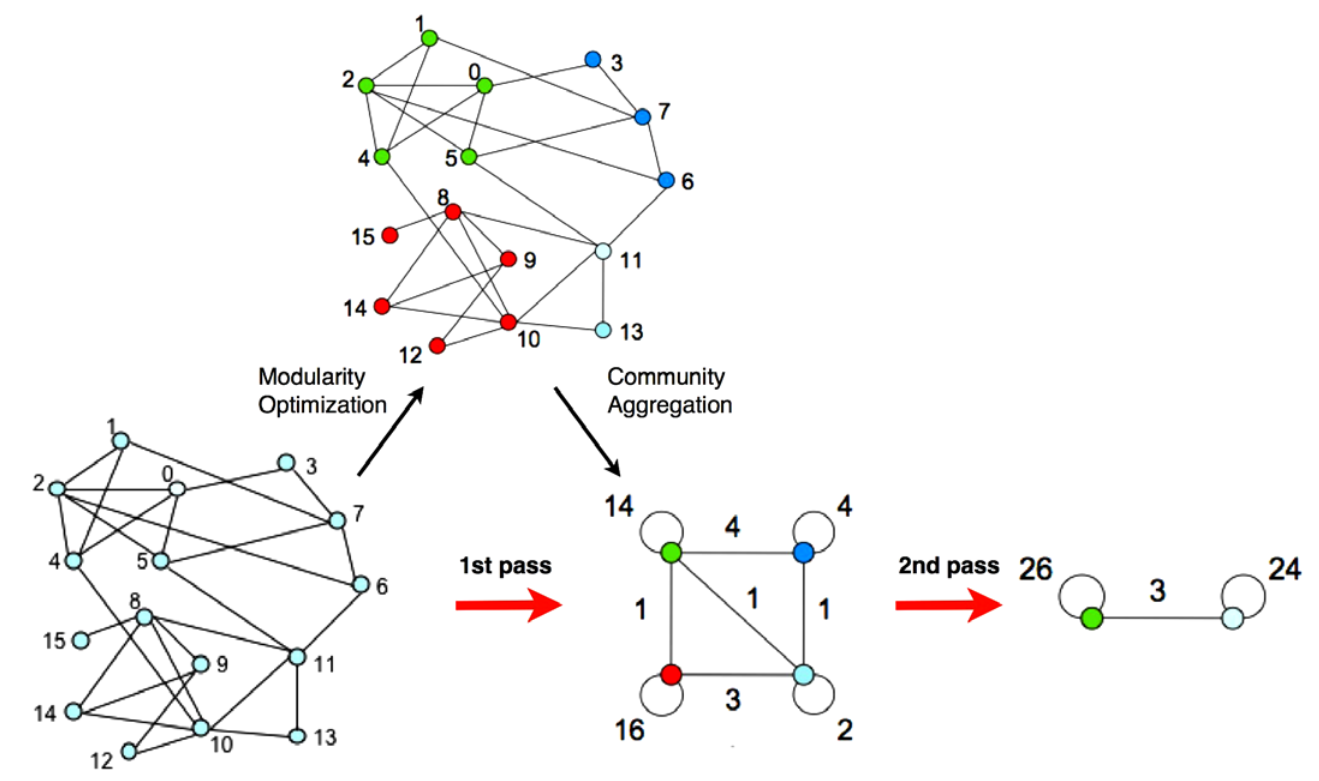

### Task 4
Use Louvain algorithm to detect communities among all studied networks. Use NetworkX function ```nx.community.louvain_communities(G, seed)```. Visualize and inspect the results.

Analyse and interpret the obtained communities, write your conclusions in the cell below.

 - Can we consider the produced split an optimal one? Change the seed value and check how it influences the obtained results, can you explain why the splits are sometimes different?

 - Compare the modularity value for generated partitions between Louvain algorithm and Girvan-Newmann algorithm. Which one is better in your opinion?

#### Code

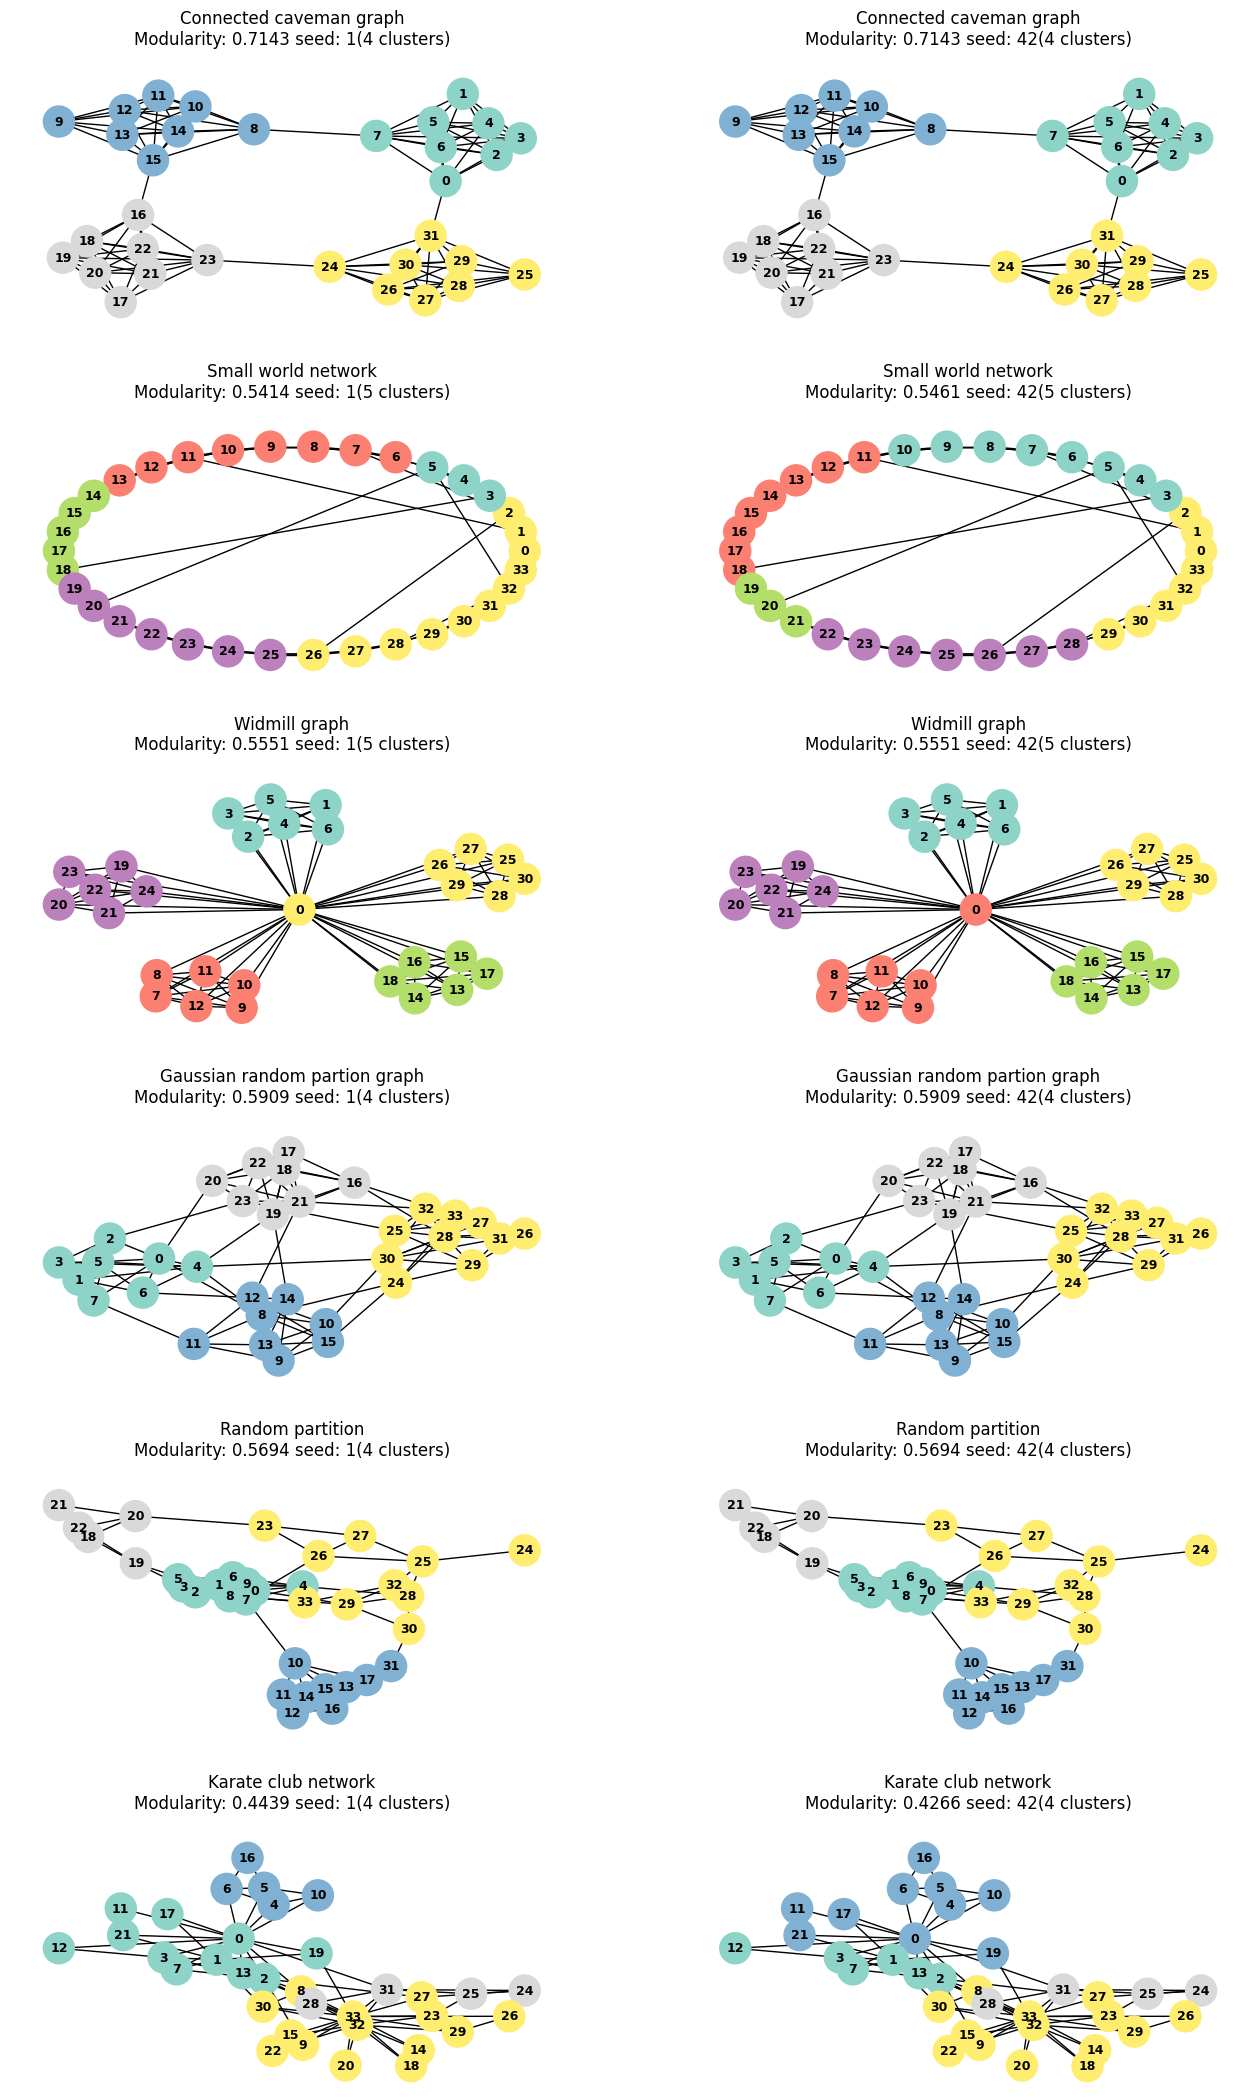

Modularity Scores (Louvain)
   Connected caveman graph (Seed 1): 0.7143
   Connected caveman graph (Seed 42): 0.7143
   Small world network (Seed 1): 0.5414
   Small world network (Seed 42): 0.5461
   Widmill graph (Seed 1): 0.5551
   Widmill graph (Seed 42): 0.5551
   Gaussian random partion graph (Seed 1): 0.5909
   Gaussian random partion graph (Seed 42): 0.5909
   Random partition (Seed 1): 0.5694
   Random partition (Seed 42): 0.5694
   Karate club network (Seed 1): 0.4439
   Karate club network (Seed 42): 0.4266


In [13]:
from networkx.algorithms.community import louvain_communities

plt.style.use('default')

modularities_gn = {}

fig, axes = plt.subplots(6, 2, figsize=(16, 24))
axes = axes.flatten()
for i, (name, graph) in enumerate(graphs.items()):
    for j, seed in enumerate([1, 42]):
        ax_idx = i * 2 + j

        communities = louvain_communities(graph, seed=seed)
        current_modularity = modularity(graph, communities)
        modularities_gn[f"{name} (Seed {seed})"] = current_modularity

        node_to_community = {}
        for community_id, community in enumerate(communities):
            for node in community:
                node_to_community[node] = community_id

        node_colors = [node_to_community[node] for node in graph.nodes()]

        if name == "Small world network":
            pos = nx.circular_layout(graph)
        elif name == "Connected caveman graph":
            pos = nx.kamada_kawai_layout(graph)
        else:
            pos = nx.spring_layout(graph, seed=42)

        axes[ax_idx].set_facecolor('white')
        nx.draw_networkx(
            graph,
            ax=axes[ax_idx],
            pos=pos,
            with_labels=True,
            node_color=node_colors,
            cmap=plt.cm.Set3,
            node_size=500,
            font_size=9,
            font_weight='bold'
        )
        axes[ax_idx].axis('off')
        axes[ax_idx].set_title(f"{name}\nModularity: {current_modularity:.4f} seed: {seed}({len(communities)} clusters)", pad=20, fontsize=12)

plt.subplots_adjust(hspace=0.4, top=0.95)
plt.show()

print("Modularity Scores (Louvain)")
for name, score in modularities_gn.items():
    print(f"   {name}: {score:.4f}")

#### Conclusions

**Optimality and the `seed` parameter**
* Louvain is a greedy algorithm – it finds great partitions (local optima) but not always the absolute best mathematical ones.
* **`seed`** - it changes the initial random order in which nodes are grouped.
* In networks with very strong, distinct clusters (Connected caveman), changing the seed does not alter the result. In networks with ambiguous boundaries (Karate club), a different order causes boundary nodes to be absorbed into different groups, which changes the final split and modularity.

**Louvain vs. Girvan-Newman**
* The Louvain algorithm is definitively better. It achieved equal or higher modularity scores across all tested networks.
* Louvain is specifically designed from the ground up to directly maximize modularity. Additionally, it runs significantly faster, making it a much more practical choice.

## Modularity,  communities and the graph structure

### Task 5
Generate a set of artificial networks of different types (scale-free netowrks, small-world networks, random partition graphs, ...) and with varying properties (size, connectivity, ...).

Study the relationship between network metrics like average centrality measures (degree, betweenness, closeness), clustering coefficient, etc. and modularity value of partition generated with Louvain algorithm as well as number of identified communities.

Analyse and interpret the obtained results, write your conclusions in the cell below.

#### Code

In [14]:
def analyze_graph(G, graph_type):
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    n = len(G.nodes())
    if n == 0: return

    avg_degree = sum(dict(G.degree()).values()) / n
    avg_clustering = nx.average_clustering(G)

    avg_betweenness = sum(nx.betweenness_centrality(G).values()) / n
    avg_closeness = sum(nx.closeness_centrality(G).values()) / n

    communities = louvain_communities(G, seed=42)
    mod_score = modularity(G, communities)
    num_communities = len(communities)

    print(f"""
        Type: {graph_type},
        Nodes: {n},
        Avg Degree: {avg_degree:.4f},
        Avg Clustering: {avg_clustering:.4f},
        Avg Betweenness: {avg_betweenness:.4f},
        Avg Closeness: {avg_closeness:.4f},
        Modularity: {mod_score:.4f},
        Num Communities: {num_communities}
    """)

nodes = 150

for k in [4, 6, 10]:
    for p in [0.05, 0.1, 0.5]:
        G = nx.watts_strogatz_graph(nodes, k, p, seed=42)
        analyze_graph(G, 'Small-World')

for m in [2, 4, 5, 8]:
    G = nx.barabasi_albert_graph(nodes, m, seed=42)
    analyze_graph(G, 'Scale-Free')

for p in [0.02, 0.1, 0.2]:
    G = nx.erdos_renyi_graph(nodes, p, seed=42)
    analyze_graph(G, 'Random (ER)')

for p_in in [0.5, 0.8]:
    for p_out in [0.01, 0.05, 0.1]:
        G = nx.random_partition_graph([30, 30, 30, 30, 30], p_in, p_out, seed=42)
        analyze_graph(G, 'Random Partition')


        Type: Small-World,
        Nodes: 150,
        Avg Degree: 4.0000,
        Avg Clustering: 0.4467,
        Avg Betweenness: 0.0456,
        Avg Closeness: 0.1317,
        Modularity: 0.7805,
        Num Communities: 12
    

        Type: Small-World,
        Nodes: 150,
        Avg Degree: 4.0000,
        Avg Clustering: 0.3702,
        Avg Betweenness: 0.0304,
        Avg Closeness: 0.1835,
        Modularity: 0.7444,
        Num Communities: 11
    

        Type: Small-World,
        Nodes: 150,
        Avg Degree: 4.0000,
        Avg Clustering: 0.0770,
        Avg Betweenness: 0.0196,
        Avg Closeness: 0.2576,
        Modularity: 0.5326,
        Num Communities: 10
    

        Type: Small-World,
        Nodes: 150,
        Avg Degree: 6.0000,
        Avg Clustering: 0.5362,
        Avg Betweenness: 0.0278,
        Avg Closeness: 0.1969,
        Modularity: 0.7444,
        Num Communities: 9
    

        Type: Small-World,
        Nodes: 150,
        Avg Degree: 6

#### Conclusions

**1. Random Partition (Graphs with built-in structure)**
* The algorithm perfectly recognized the built-in structure, regardless of edge density.
* When nodes within groups are strongly connected (clustering >0.7), modularity reaches its peak (>0.74).
* As the overall edge density (Average Degree) increases, the boundaries between groups blur, and modularity drops.

**2. Small-World Networks**
* They partition very well as long as they maintain high regularity and local connections.
* When the network becomes more random (clustering drops from ~0.53 to ~0.11), its modularity crashes drastically (dropping from 0.74 to 0.45), and distinct groups disappear.

**3. Scale-Free Networks**
* They achieve the **lowest modularity scores** overall (often below 0.30).
* This is due to their structure: they are dominated by "hubs" (single nodes with a massive number of connections) that tie the whole network together, preventing the formation of clearly isolated communities.

**4. Random (Erdős-Rényi) Networks**
* They lack any natural community structure (extremely low clustering).
* The algorithm only finds distinct groups (and satisfactory modularity ~0.63) when the network is very sparse (Average Degree < 3).
* When the network becomes denser (Average Degree ~30), modularity drops almost to zero (0.13), and the network turns into one massive, interconnected blob.

A high clustering coefficient always favors high modularity. Conversely, a high average degree (high density) always leads to a drop in modularity and forces small groups to merge into fewer, larger clusters.

## Real world data use-case
The data is a history of internal e-mail communication (`sender, recipient, datetime`) between employees of a mid-sized manufacturing company. Multiple recipients of the same e-mail (`To, CC, BCC`) are represented as separate rows without distinguishing the recipient type. The period covered are nine full months (event dates in local time). The file containing the communication events is named `communication.csv`.

Apart from the communication, information about who in the company reports to whom is attached (`reportsto.csv`). Node #86 is CEO.

### Data preparation

In [15]:
import sys
! apt-get install -y libgraphviz-dev pkg-config
! {sys.executable} -m pip install pygraphviz

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Load raw events data

In [16]:
import requests
from pathlib import Path

data_file = Path("communication.tab")
if not data_file.exists():
    r = requests.get("https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/KWTRDM")
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ''))

# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

raw_df = pd.read_table(data_file, sep=';', header=0,  parse_dates=["EventDate"])

Load company hierarchy

In [17]:
data_file = Path("reportsto.tab")
if not data_file.exists():
    r = requests.get("https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/SMALXX")
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ''))

# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

reportsto = pd.read_csv(data_file, sep=";")

Clean dataset

In [18]:
non_employee_accounts = reportsto[reportsto.ReportsToID.apply(lambda x: not x.isnumeric())]
rows_to_remove = raw_df.loc[raw_df["Sender"].isin(non_employee_accounts["ID"]) | raw_df["Recipient"].isin(non_employee_accounts["ID"])]
raw_df = raw_df.drop(rows_to_remove.index)
reportsto = reportsto.drop(non_employee_accounts.index)

Plot company hierarchy

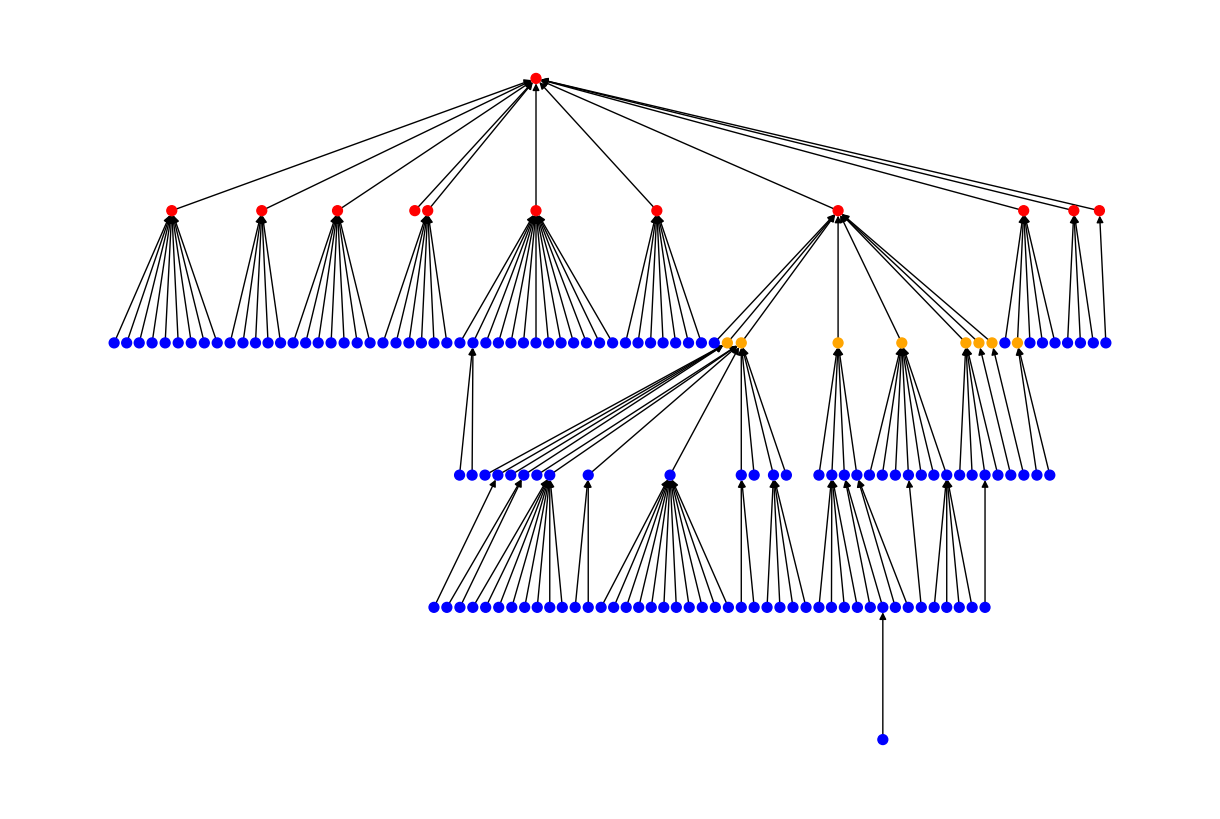

In [19]:
first_management_level = [86, 7, 27, 36, 69, 70, 85, 104, 121, 148, 156, 163]
second_management_level = [76, 90, 136, 137, 143, 152, 47, 162]

H = nx.DiGraph()

for index, row in reportsto.iterrows():
  employee = row['ID']
  supervisor = int(row['ReportsToID'])
  communication_nodes = set(raw_df["Sender"].values + raw_df["Recipient"].values)
  if employee != supervisor and (employee in communication_nodes or supervisor in communication_nodes):
    H.add_edge(employee, supervisor)

color_map = []
for node in H:
  if node in first_management_level:
    color_map.append("red")
  elif node in second_management_level:
    color_map.append("orange")
  else:
    color_map.append("blue")

plt.figure(figsize=(12, 8))
pos_hierarchic = nx.nx_agraph.graphviz_layout(H, prog='dot')
pos_hierarchic = {node: (x,-y) for (node, (x,y)) in pos_hierarchic.items()}
nx.draw(H, pos=pos_hierarchic, with_labels=False, arrows=True, node_size=50, node_color=color_map)

plt.show()

### Task 6
Create a weighted network from the communication data (see Section "Data preparation above").
Check if you can find communities in this real world network. Try different algorithms and approaches.

Can weight of the edges be used in that context? What type of graph representation can be an input to the community detection method you use?

Visualize communities using hirarchy positioning defined in the cell above. For the clarity of visualizations, use only edges from hierarchy company structure.

Analyse and interpret the obtained results, write your conclusions in the cell below. Answer the question: How can this kind of network analysis and exploration be leveraged in the company to improve its functioning?

#### Code

Louvain algorithm identified 9 communities.
Greedy Modularity identified 8 communities.


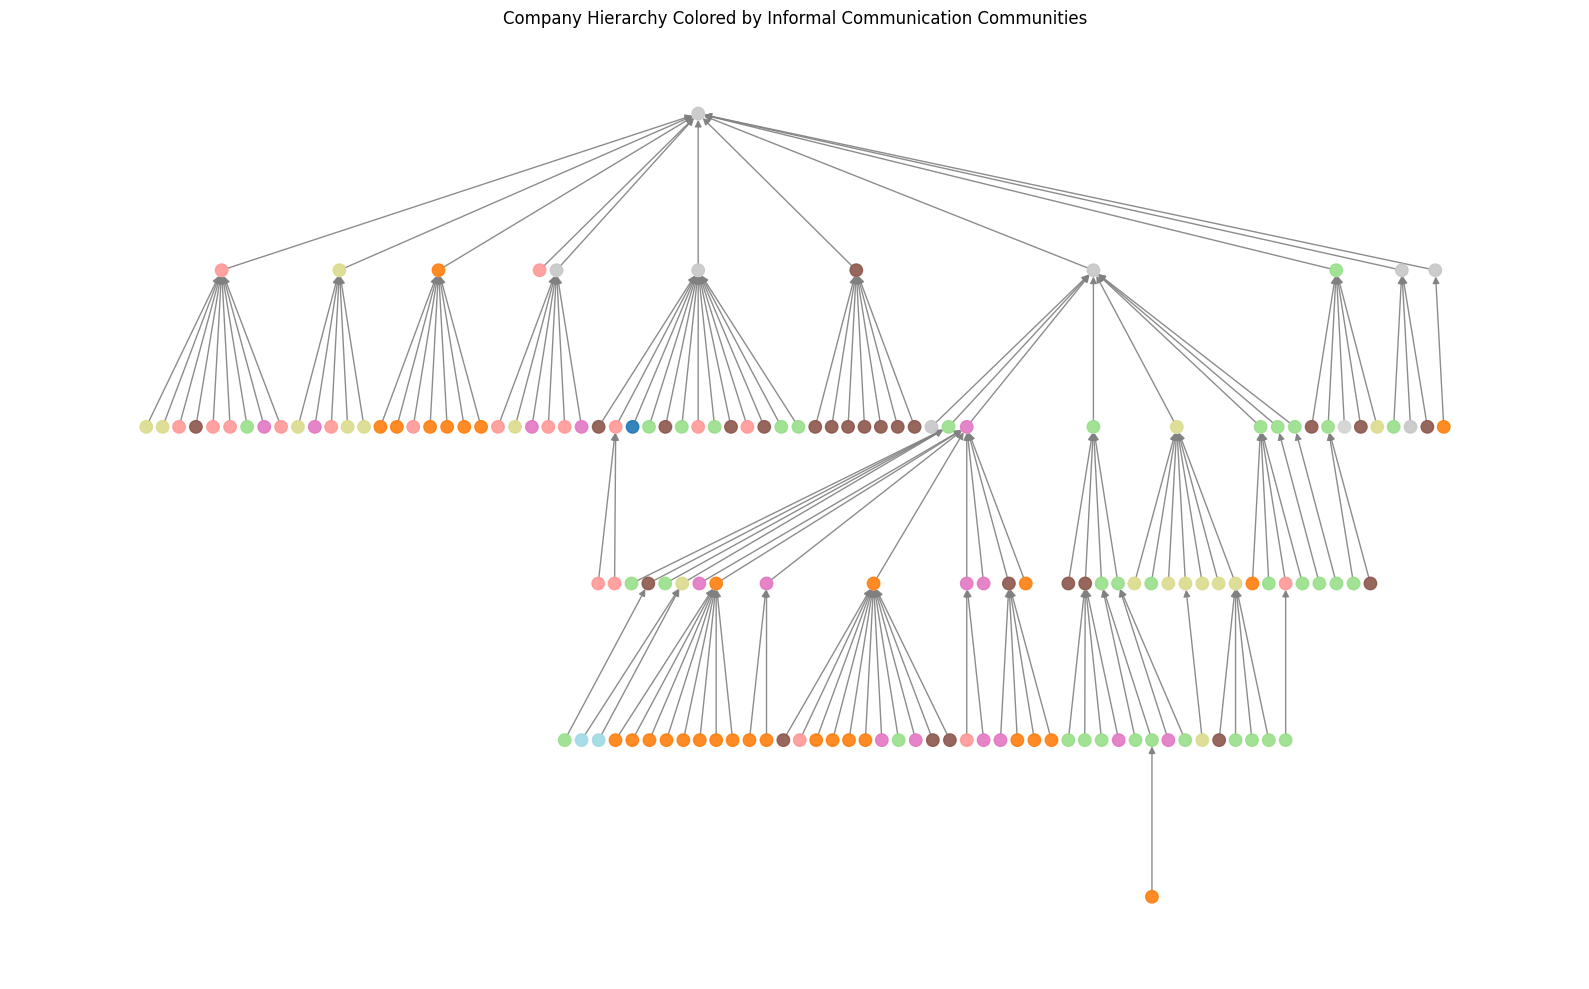

In [23]:
from networkx.algorithms.community import greedy_modularity_communities

comm_counts = raw_df.groupby(['Sender', 'Recipient']).size().reset_index(name='weight')

G_comm = nx.from_pandas_edgelist(
    comm_counts, 
    source='Sender', 
    target='Recipient', 
    edge_attr='weight', 
    create_using=nx.Graph()
)

louvain_comms = louvain_communities(G_comm, weight='weight', seed=42)
greedy_comms = greedy_modularity_communities(G_comm, weight='weight')

print(f"Louvain algorithm identified {len(louvain_comms)} communities.")
print(f"Greedy Modularity identified {len(greedy_comms)} communities.")

node_to_comm = {}
for comm_id, comm in enumerate(louvain_comms):
    for node in comm:
        node_to_comm[node] = comm_id

cmap = plt.get_cmap('tab20', len(louvain_comms))
node_colors = []
for node in H.nodes():
    if node in node_to_comm:
        node_colors.append(cmap(node_to_comm[node]))
    else:
        node_colors.append('lightgrey') 

plt.figure(figsize=(16, 10))
plt.gca().set_facecolor('white')

nx.draw(
    H, 
    pos=pos_hierarchic, 
    with_labels=False, 
    arrows=True, 
    node_size=80, 
    node_color=node_colors,
    edge_color='gray',
    alpha=0.9
)

plt.title("Company Hierarchy Colored by Informal Communication Communities")
plt.axis('off')
plt.tight_layout()
plt.show()

#### Conclusions

* The official hierarchy (tree shape) completely misaligns with informal communication (scattered colors). People do not collaborate the way the organizational chart dictates.

* "Shadow networks" are visible-employees from completely different branches of the company (reporting to different managers) form their own strong communication groups (represented by the same colors).

* The rigid, tree-like structure blocks natural collaboration. The company should consider flattening the hierarchy or shifting to a matrix/project-based model that actually reflects the real flow of information.